# Dryft modelu

Dryft modelu to spadek jakości względem bazowej wydajności (np. AUC, accuracy, F1) po pewnym czasie w produkcji, mimo że architektura i wagi modelu się nie zmieniają.

**Przyczyną są zmiany statystycznych własności danych wejściowych, rozkładu etykiet albo relacji wejście–wyjście, więc model zaczyna „nie rozumieć” nowych przypadków.** 

Przykład: *model scoringu kredytowego trenowany na danych sprzed pandemii traci skuteczność w czasie kryzysu, bo zmienia się zachowanie klientów i profil ryzyka*.

## Rodzaje dryftu: data vs concept

Najczęściej rozróżnia się **data drift** i **concept drift** (często utożsamiany z model driftem). 

---

**Data drift** (covariate shift): zmienia się rozkład cech $P(X)$, ale relacja $P(Y|X)$ może pozostać taka sama.  

Data drift typowo wykrywamy testami na rozkładach cech (KS, PSI, chi‑kwadrat, miary odległości rozkładów) i reagujemy aktualizacją preprocessing/re‑samplingiem oraz ponownym trenowaniem na nowych danych.

Można wyróżnić dwie główne kategorie:

a) **Dryf etykiet** (label drift).  Zmienia się rozkład wartości wyjściowych (etykiet), czyli prawdopodobieństwo zmiennej prognozowanej.

Przykład: *Zmienia się ogólny poziom niespłacalności w systemie, np. w kryzysie gwałtownie rośnie odsetek niespłaconych kredytów, nawet jeśli profil klientów wygląda podobnie jak dawniej*.

b) **Dryf zmiennych** (feature drift). Zmienia się rozkład wartości wejściowych (cech), czyli prawdopodobieństwo danych wejściowych.

Przykład: *zmienia się profil klientów, którzy składają wnioski o kredyt: np. nagle jest więcej osób z branż o niestabilnych dochodach albo więcej krótkich umów cywilnoprawnych*.

---

**Concept/model drift**: zmienia się relacja między cechami a celem $P(Y|X)$, nawet jeśli rozkład cech wygląda podobnie.

Concept drift wykrywamy głównie przez monitoring metryk modelu w czasie (AUC, F1 itd.), metody sekwencyjne i analizę okien czasowych, a reakcją jest przeprojektowanie cech, ewentualnie architektury, a czasem nawet redefinicja zadania.

---

<center><img src="./Images/model_drift.png" alt="Model drift" width="300"></center> M.Mamczur

## Szybkość wystąpienia dryfu

*Nie warto pytać, czy model zacznie dryfować, tylko kiedy to się stanie. &#128578; *

Sposób, w jaki dryf się pojawia, może być bardzo różny:

* **Nagły dryf** – zmiana praktycznie z dnia na dzień (np. lockdown, wybuch wojny); model zbudowany na „starym świecie” nagle staje się nieadekwatny.

* **Dryf stopniowy** – małe zmiany kumulują się w czasie; pojedynczo są niewidoczne, ale po miesiącach metryki wyraźnie spadają.

* **Dryf impulsowy** – jednorazowy skok, zwykle przez błąd danych lub wyjątkowe, krótkotrwałe zdarzenie; po jego ustąpieniu rozkład wraca do normy.

* **Sezonowość (nawracający)** – powtarzalne wzorce (np. święta, Black Friday); wygląda jak dryf, ale jest przewidywalną strukturą sezonową, którą warto uwzględnić w modelu.

## Metody wykrywania dryfu modelu  

Najpierw pytamy: *czy wiemy już, jaki był prawdziwy wynik dla nowych przypadków (ground truth)* – czyli czy mamy etykiety. Ground truth to np. informacja, czy klient faktycznie nie spłacił kredytu, transakcja była fraudem (model oceny fałszerstw) albo pacjent rzeczywiście został ponownie przyjęty do szpital (model analizy "szybkich" powrotów do szpitala).  

**Gdy mamy etykiety (ground truth)**  
- Liczymy regularnie metryki jakości modelu (AUC, F1, precision/recall, koszt biznesowy) na najnowszym oknie danych i porównujemy z okresem trenowania. 
- Do automatycznego wykrywania spadków jakości można użyć metod sekwencyjnych: CUSUM, ADWIN, SPC itp. 

**Gdy nie mamy jeszcze etykiet (ground truth)**  
- Sprawdzamy, czy zmienił się rozkład danych wejściowych w porównaniu ze zbiorem treningowym, np. za pomocą PSI, testu KS, dywergencji KL lub Jensena‑Shannona. 
- Duże różnice w rozkładach są sygnałem, że wydajność modelu może być zagrożona, nawet jeśli jeszcze nie znamy prawdziwych wyników. 

## Analiza przyczyny dryfu modelu

- Najpierw upewnij się, że nie ma problemu z integralnością danych: sprawdź pipeline’y, błędy w ETL, zmiany API, nagłe braki wartości, nowe kategorie poza pierwotnym zakresem.

- Gdy dane technicznie są poprawne, szukaj rzeczywistych zmian w danych: porównuj rozkłady cech i etykiet do okresu trenowania, szczególnie dla zmiennych ważnych dla modelu, w oknach czasowych (tygodnie/miesiące).

- Analizuj dryf z osobami mającymi wiedzę domenową (analityk, właściciel procesu, klinicysta) oraz po segmentach (wiek, kanał, region) – często to dopiero wtedy ujawnia prawdziwe źródło zmiany.

## Naprawa modelu po wykryciu dryfu

- Najpierw napraw ewentualne problemy techniczne: sprawdź pipeline z danymi, błędne zasilenia, zmiany API, pojawienie się pustych wartości lub nowych, niespodziewanych kategorii.

- Jeśli dane są poprawne, przetrenuj model na nowszych danych (przesunięte okno czasowe), ewentualnie zmień strategię trenowania: tylko najnowsze dane, miks starych i nowych, większa waga dla świeżych przykładów.

- Możesz:

    - przełączać modele zależnie od cyklu / sezonu (różne modele na różne okresy),
    - skorygować próg decyzyjny w segmentach, gdzie model najbardziej się pogorszył, zamiast od razu go przebudowywać. </br></br>
      

- W systemach z częstym retrainingiem (np. nowy model co miesiąc) dryf danych jest ograniczany automatycznie, ale rośnie znaczenie procesów MLOps (Machine Learning Operations – zbiór praktyk i narzędzi do wdrażania, monitorowania i utrzymania modeli ML w produkcji): testy, walidacja, bezpieczne wdrożenia.

# Przykład (teoretyczny)

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
rng = np.random.default_rng(42)
# Zalecane zamiast np.random.seed(42),
# bo tworzy osobny, lokalny generator liczb losowych, zamiast ustawiać globalny stan generatora dla całego modułu np.random.
# Uwaga: oba podejścia nie muszą dawać tych samych liczb dla tego samego ziarna 42, ponieważ używają innego mechanizmu generatora.

-----
**Dane treningowe (brak dryfu)**

Generujemy dane do klasyfikacji binarnej:

* x_train to losowa zmienna wejściowa z rozkładu normalnego.
* logit określa liniową zależność między x_train a prawdopodobieństwem klasy 1.
* p to prawdopodobieństwo uzyskane po przekształceniu logit funkcją logistyczną.
* y_train to etykieta klasy 0 lub 1, losowana zgodnie z prawdopodobieństwem p.

Czyli: większe x_train zwiększa prawdopodobieństwo, że y_train = 1.

In [3]:
n_train = 5000
x_train = rng.normal(loc=0.0, scale=1.0, size=n_train)
logit = 1.0 * x_train  # prosty związek
p = 1 / (1 + np.exp(-logit))
y_train = rng.binomial(1, p)

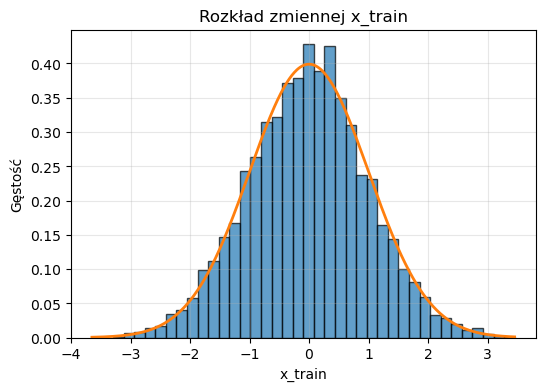

In [4]:
# rozkład empiryczny x_train
plt.figure(figsize=(6, 4))
plt.hist(x_train,    bins=40,    density=True,    alpha=0.7,    edgecolor="black")
# teoretyczna krzywa rozkładu normalnego N(0, 1)
x = np.linspace(x_train.min(), x_train.max(), 500)
gestosc = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)
plt.plot(x, gestosc, linewidth=2)
plt.xlabel("x_train")
plt.ylabel("Gęstość")
plt.title("Rozkład zmiennej x_train")
plt.grid(alpha=0.3)
plt.show()

Podział danych:

In [5]:
X_train, X_val, y_train_split, y_val = train_test_split(
    x_train.reshape(-1, 1), y_train, test_size=0.3, random_state=42
)

Tworzenie modelu i liczenie metryki AUC:

In [6]:
model = LogisticRegression()
model.fit(X_train, y_train_split)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [7]:
auc_val = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
print(f"AUC na danych walidacyjnych (bez dryfu): {auc_val:.3f}")

AUC na danych walidacyjnych (bez dryfu): 0.764


------
**Dane po dryfie danych (przesunięty rozkład cechy)**

In [8]:
n_new = 5000
x_new = rng.normal(loc=1.5, scale=1.0, size=n_new)  # przesunięta średnia
logit_new = 1.0 * x_new
p_new = 1 / (1 + np.exp(-logit_new))
y_new = rng.binomial(1, p_new)

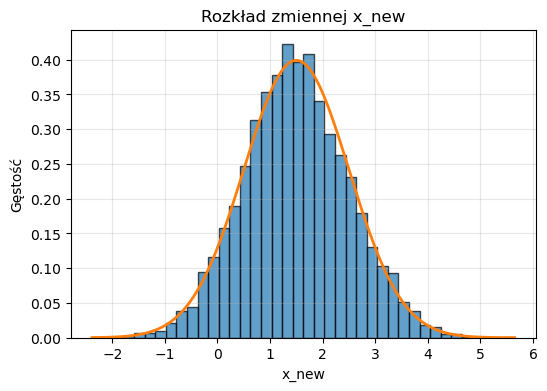

In [9]:
# rozkład empiryczny x_new
plt.figure(figsize=(6, 4))
plt.hist(x_new,    bins=40,    density=True,    alpha=0.7,    edgecolor="black")
# teoretyczna krzywa rozkładu normalnego N(1.5, 1)
x = np.linspace(x_new.min(), x_new.max(), 500)
gestosc = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * (x - 1.5)**2)
plt.plot(x, gestosc, linewidth=2)
plt.xlabel("x_new")
plt.ylabel("Gęstość")
plt.title("Rozkład zmiennej x_new")
plt.grid(alpha=0.3)
plt.show()

In [10]:
auc_new = roc_auc_score(y_new, model.predict_proba(x_new.reshape(-1, 1))[:, 1])
print(f"AUC na nowych danych (po dryfie): {auc_new:.3f}")

AUC na nowych danych (po dryfie): 0.739


**Różnica AUC z 0.764 do 0.739 oznacza zauważalny, ale jeszcze umiarkowany spadek jakości modelu – raczej sygnał „warto obserwować”, a nie od razu „model do wyrzucenia”.**

*W tym przykładzie mieliśmy dostęp do targetu, więc degradację jakości mogliśmy zmierzyć bezpośrednio na etykietach, a nie tylko pośrednio przez dryf danych wejściowych.*

-----
**Prosty test dryfu danych – KS**

* Test Kołmogorowa‑Smirnowa (KS) porównuje dwa zbiory wartości jednej zmiennej i sprawdza, czy pochodzą z tego samego rozkładu.

* W kontekście dryfu: porówniasz rozkład cechy w danych treningowych z rozkładem tej samej cechy w nowych danych; duża wartość statystyki KS i małe p-value sugerują istotny dryf.

* KS dobrze nadaje się do cech ciągłych, jest nieparametryczny (nie zakłada konkretnego kształtu rozkładu) i czuły na zmiany zarówno położenia, jak i kształtu rozkładu.

In [11]:
ks_stat, ks_p = ks_2samp(x_train, x_new)
print(f"KS stat = {ks_stat:.3f}, p-value = {ks_p:.3e}")

KS stat = 0.565, p-value = 0.000e+00


Wynik testu KS (statystyka 0.565, p ≈ 0) wskazuje, że rozkład tej cechy w nowych danych istotnie różni się od rozkładu w zbiorze treningowym, co jest silnym sygnałem data driftu.

-----
**Wizualizacja rozkładów cechy**

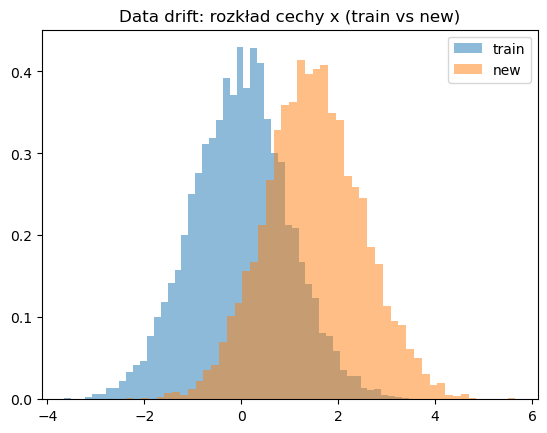

In [12]:
plt.hist(x_train, bins=50, alpha=0.5, label="train", density=True)
plt.hist(x_new,   bins=50, alpha=0.5, label="new",   density=True)
plt.legend()
plt.title("Data drift: rozkład cechy x (train vs new)")
plt.show()

Ten wykres pokazuje, jak zmienił się rozkład cechy x między zbiorem treningowym (train) a nowymi danymi (new) – jeśli histogramy są mocno przesunięte (tak, jak tutaj) lub mają inny kształt, to jest to wizualny dowód data driftu dla analizowanej zmiennej.

# Przykład (case study)

**Wczesne wykrywanie ryzyka ponownego przyjęcia pacjenta do szpitala (hospital readmission) - case study**

<div style="text-align: center;"><img src=".//Images//Hospital_scene.png" alt="zadanie" width="400" height="120" style="margin: 10px; "/></div>

**Cel projektu**

W systemach opieki zdrowotnej ponowne przyjęcia pacjentów do szpitala w krótkim czasie po wypisie (np. w ciągu 30 dni) są poważnym problemem. Powodują dodatkowe koszty, zajmują miejsca szpitalne i mogą świadczyć o niewłaściwej opiece lub nieprzestrzeganiu zaleceń przez pacjenta. Celem projektu jest stworzenie modelu klasyfikacyjnego, który przewidzi z dużym wyprzedzeniem, czy pacjent zostanie ponownie przyjęty do szpitala w ciągu 30 dni od wypisu.

---

**Dane źródłowe**

Zbiór danych (dostępny lokalnie) pochodzi z repozytorium UCI Machine Learning:
**"Diabetes 130-US hospitals for years 1999–2008"**  
[Link do zbioru](https://archive.ics.uci.edu/ml/datasets/diabetes)

- Liczba rekordów: ~100 000  
- Źródło: dane z 130 szpitali w USA  
- Opis: każdy wiersz to jeden pobyt pacjenta chorego na cukrzycę  
- Atrybuty: dane demograficzne (wiek, płeć), długość pobytu, leki, zabiegi, diagnozy, liczba wizyt ambulatoryjnych itp.  

---

**Zmienna docelowa**  

Kolumna `readmitted` zawiera wartości:  
- `'NO'` – brak ponownego przyjęcia  
- `'>30'` – przyjęcie po ponad 30 dniach  
- `'<30'` – przyjęcie w ciągu 30 dni  

**Dla celów klasyfikacji binarnej przekształcamy:**  
- `y = 1` jeśli `readmitted == '<30'`  
- `y = 0` w przeciwnym razie  

---

**Zadanie**

Zbadaj dla kolejnych odcinków czasu dryft danych.

---

**Importy i ustawienia**

In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

RANDOM_STATE = 42

-----

**Wczytanie danych**  (plik 'diabetic_data.csv' z UCI)

In [14]:
df = pd.read_csv("./Data/diabetic_data.csv")
print(df.shape)

(101766, 50)


------
**Proste czyszczenie + target**

* Kolumna 'readmitted' ma wartości: '<30', '>30', 'NO'
* Target: readmission <30 days vs reszta
* Na potrzeby przykładu wybierzemy kilka prostych cech:
    - **age** – przedział wiekowy pacjenta w momencie hospitalizacji,
    - **time_in_hospital** – liczba dni spędzonych w szpitalu podczas danego pobytu,
    - **num_lab_procedures** – liczba wykonanych badań laboratoryjnych,
    - **num_medications** – liczba leków podanych pacjentowi,
    - **number_inpatient** – liczba wcześniejszych hospitalizacji stacjonarnych,
    - **race** – grupa rasowa/etniczna pacjenta,
    - **gender** – płeć pacjenta.

In [15]:
df["readmit_30d"] = (df["readmitted"] == "<30").astype(int)

features_num = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications",
    "number_inpatient",
]
features_cat = ["age", "race", "gender"]

used_cols = features_num + features_cat + ["readmit_30d", "admission_type_id"]

df_sub = df[used_cols].copy()

Usunięcie braków (w najprostszy sposób poprzez usunięcie)

In [16]:
df_sub = df_sub.replace("?", np.nan)
df_sub = df_sub.dropna()

print(df_sub.shape)

(99493, 9)


-----
**Pseudo-czas: podział na "okres trenowania" i "okna"**

* Dataset nie ma jawnego roku, więc użyjemy **admission_type_id** tylko jako *przykładowego* czasu do segmentacji.
* W realnym projekcie użylibyśmy prawdziwej osi czasu (data przyjęcia).

In [17]:
# Zmiana nazwy kolumny:
# admission_type_id będzie dalej traktowane jako zmienna opisująca rok
df_sub.rename(columns={"admission_type_id": "year"}, inplace=True)

# Pobranie unikalnych, niepustych wartości z kolumny year
# Następnie wartości są sortowane rosnąco
unique_values = sorted(df_sub["year"].dropna().unique())

# Utworzenie mapowania starych wartości na kolejne lata
# Najmniejsza wartość otrzyma rok 2018, kolejna 2019 itd.
map_years = {year: 2018 + i for i, year in enumerate(unique_values)}

# Zastąpienie oryginalnych wartości w kolumnie year nowymi wartościami lat
df_sub["year"] = df_sub["year"].map(map_years)

# Utworzenie maski logicznej:
# dane z lat do 2020 włącznie zostaną użyte jako dane treningowe
train_mask = df_sub["year"] <= 2020

# Wyodrębnienie danych treningowych
df_train_all = df_sub[train_mask].copy()

# Wyodrębnienie danych późniejszych, czyli takich,
# które pojawiły się po okresie treningowym
df_future = df_sub[~train_mask].copy()

# Wyświetlenie rozmiarów zbiorów
print("Dane treningowe do modelu:", df_train_all.shape)
print("Dane, który pojawiły się po pewnym czasie:", df_future.shape)

Dane treningowe do modelu: (89194, 9)
Dane, który pojawiły się po pewnym czasie: (10299, 9)


In [18]:
df_train_all

,time_in_hospital,num_lab_procedures,num_medications,number_inpatient,age,race,gender,readmit_30d,year
1,3,59,18,0,[10-20),Caucasian,Female,0,2018
2,2,11,13,1,[20-30),AfricanAmerican,Female,0,2018
3,2,44,16,0,[30-40),Caucasian,Male,0,2018
4,1,51,8,0,[40-50),Caucasian,Male,0,2018
5,3,31,16,0,[50-60),Caucasian,Male,0,2019
...,...,...,...,...,...,...,...,...,...
101761,3,51,16,0,[70-80),AfricanAmerican,Male,0,2018
101762,5,33,18,1,[80-90),AfricanAmerican,Female,0,2018
101763,1,53,9,0,[70-80),Caucasian,Male,0,2018
101764,10,45,21,1,[80-90),Caucasian,Female,0,2019


-----
**Przygotowanie X, y + pipeline**

In [19]:
X_train_all = df_train_all[features_num + features_cat]
y_train_all = df_train_all["readmit_30d"]

Podział train/val (walidacja bez dryfu – referencyjna jakość)

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_all,
    y_train_all,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y_train_all,
)

Transformacje: one-hot dla kategorii, "passthrough" dla numerycznych ("passthrough" oznacza, że te kolumny mają zostać przepuszczone bez żadnej transformacji).

In [21]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", features_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat),
    ]
)

clf = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000, n_jobs=-1, class_weight='balanced')),
    ]
)

Trening na danych "historycznych"

In [22]:
clf.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Referencyjna AUC (bez dryfu):

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [24]:
# Referencyjna AUC (bez dryfu)
y_val_pred = clf.predict_proba(X_val)[:, 1]
auc_ref = roc_auc_score(y_val, y_val_pred)

# scores mamy już w y_val_pred
y_val_pred_label = (y_val_pred >= 0.5).astype(int)

prec_ref = precision_score(y_val, y_val_pred_label)
rec_ref  = recall_score(y_val, y_val_pred_label)
f1_ref   = f1_score(y_val, y_val_pred_label)

print(f"Referencyjna AUC: {auc_ref:.3f}")
print(f"Precision (val, thr=0.5): {prec_ref:.3f}")
print(f"Recall    (val, thr=0.5): {rec_ref:.3f}")
print(f"F1        (val, thr=0.5): {f1_ref:.3f}")

Referencyjna AUC: 0.627
Precision (val, thr=0.5): 0.169
Recall    (val, thr=0.5): 0.464
F1        (val, thr=0.5): 0.248


Do porównywania modeli przed i po dryfie użyjemy AUC, bo jest niezależne od konkretnego progu decyzyjnego i mierzy ogólną zdolność modelu do rozróżniania klas, podczas gdy precision, recall i F1 silnie zależą od wybranego progu i konkretnej struktury klas w danym zbiorze.

-----
**Analiza dryfu w kolejnych "oknach czasowych"**

*Potraktujmy różne wartości year jako kolejne okresy.*

In [25]:
future_times = [int(t) for t in sorted(df_future["year"].unique())]
print("Kolejne lata (future):", future_times)

auc_list = []
ks_list_time_in_hosp = []

for t in future_times:
    df_period = df_future[df_future["year"] == t]
    if df_period.shape[0] < 200:
        # zbyt mała próbka, pomijamy
        continue

    X_period = df_period[features_num + features_cat]
    y_period = df_period["readmit_30d"]

    # AUC modelu na tym okresie
    y_pred_period = clf.predict_proba(X_period)[:, 1]
    auc_t = roc_auc_score(y_period, y_pred_period)
    auc_list.append((int(t), auc_t))

    # Przykładowy test KS dla jednej cechy numerycznej
    ks_stat, ks_p = ks_2samp(
        df_train_all["time_in_hospital"],
        df_period["time_in_hospital"],
    )
    ks_list_time_in_hosp.append((int(t), ks_stat, ks_p))

Kolejne lata (future): [2021, 2022, 2023, 2024, 2025]


Wyniki AUC:

In [26]:
print("\nAUC w kolejnych latach (pominięto małe próbki):")
for t, auc_t in auc_list:
    print(f"  rok={t}: AUC = {auc_t:.3f}")


AUC w kolejnych latach (pominięto małe próbki):
  rok=2022: AUC = 0.597
  rok=2023: AUC = 0.653
  rok=2025: AUC = 0.566


Te wyniki sugerują, że jakość modelu nie jest stabilna w czasie.


Wyniki KS:

In [27]:
print("\nKS dla 'time_in_hospital' (train vs okres):")
for t, ks_stat, ks_p in ks_list_time_in_hosp:
    print(f"  rok={t}: KS={ks_stat:.3f}, p={ks_p:.1e}")


KS dla 'time_in_hospital' (train vs okres):
  rok=2022: KS=0.072, p=8.0e-21
  rok=2023: KS=0.033, p=5.1e-05
  rok=2025: KS=0.352, p=1.8e-35


* 2022 - różnica rozkładów jest mała, ale statystycznie istotna. Przy dużych próbkach nawet niewielkie przesunięcia dają bardzo małe p, więc tu ważniejsza jest sama wartość KS = 0.072 niż p-value.
* 2023 - różnica jest bardzo mała; rozkład tej cechy jest dość zbliżony do okresu treningowego.
* 2025 - to już silny data drift. Rozkład time_in_hospital w 2025 wyraźnie odbiega od treningowego.

------
**Prosty wykres AUC w czasie**

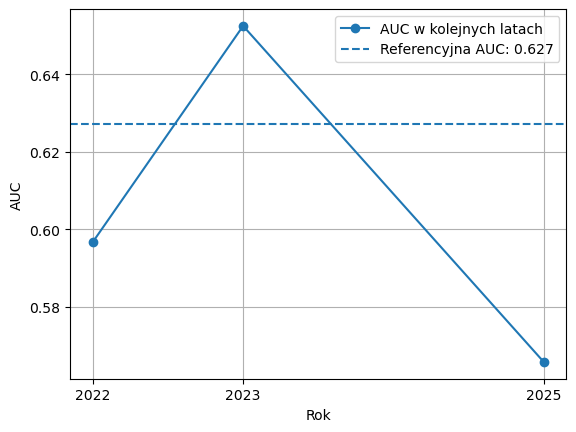

In [28]:
if auc_list:
    times = [int(t) for t, _ in auc_list]
    aucs = [a for _, a in auc_list]

    plt.plot(times, aucs, marker="o", label="AUC w kolejnych latach")
    plt.axhline(y=auc_ref, linestyle="--", label=f"Referencyjna AUC: {auc_ref:.3f}")

    plt.xlabel("Rok")
    plt.ylabel("AUC")
    plt.xticks(sorted(set(times)))
    plt.grid(True)
    plt.legend()
    plt.show()

-----
**Porównanie rozkładów cechy (data drift)**

Porównamy rozkład 'time_in_hospital' dla train vs jednego z okresów future (ostatni rok)

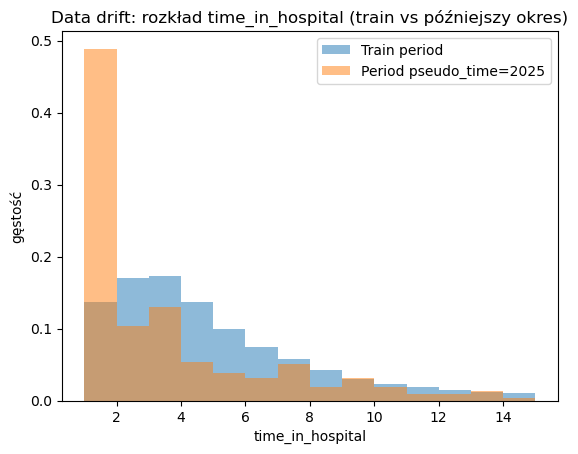

In [29]:
if future_times:
    t_example = future_times[-1]
    df_period_example = df_future[df_future["year"] == t_example]

    # podział powinien być na równe całkowite części, inaczej mogłyby być "dziury" :)
    min_val = min(df_train_all["time_in_hospital"].min(), df_period_example["time_in_hospital"].min())
    max_val = max(df_train_all["time_in_hospital"].max(), df_period_example["time_in_hospital"].max())
    bins = range(min_val, max_val + 2)

    plt.hist(
        df_train_all["time_in_hospital"],
        bins=bins,
        alpha=0.5,
        label="Train period",
        density=True,
    )
    plt.hist(
        df_period_example["time_in_hospital"],
        bins=bins,
        alpha=0.5,
        label=f"Period pseudo_time={t_example}",
        density=True,
    )
    plt.xlabel("time_in_hospital")
    plt.ylabel("gęstość")
    plt.title("Data drift: rozkład time_in_hospital (train vs późniejszy okres)")
    plt.legend()
    plt.show()

W 2025 rozkład time_in_hospital wyraźnie przesunął się względem okresu treningowego: widać dużo większy udział bardzo krótkich hospitalizacji, zwłaszcza 1–2 dni. To potwierdza obecność data drift i może częściowo tłumaczyć spadek jakości modelu w tym okresie.

------
**Korekta progu decyzyjnego w ostatnim okresie**

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score

# bierzemy ostatni okres z listy użytej w auc_list / ks_list_time_in_hosp
last_time = times[-1]
df_last = df_future[df_future["year"] == last_time].copy()

X_last = df_last[features_num + features_cat]
y_last = df_last["readmit_30d"]
y_scores_last = clf.predict_proba(X_last)[:, 1]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

rows = []
for thr in thresholds:
    y_pred_thr = (y_scores_last >= thr).astype(int)
    prec = precision_score(y_last, y_pred_thr)
    rec  = recall_score(y_last, y_pred_thr)
    f1   = f1_score(y_last, y_pred_thr)
    rows.append({"threshold": thr, "precision": prec, "recall": rec, "f1": f1})

df_thresholds = pd.DataFrame(rows)

print(f"\nMetryki w zbiorze treningowym:")
print(f"Referencyjna AUC: {auc_ref:.3f}")
print(f"Precision (val, thr=0.5): {prec_ref:.3f}")
print(f"Recall    (val, thr=0.5): {rec_ref:.3f}")
print(f"F1        (val, thr=0.5): {f1_ref:.3f}")
print(f"\nMetryki w ostatnim okresie (rok={last_time}) dla różnych progów:")
print(df_thresholds)


Metryki w zbiorze treningowym:
Referencyjna AUC: 0.627
Precision (val, thr=0.5): 0.169
Recall    (val, thr=0.5): 0.464
F1        (val, thr=0.5): 0.248

Metryki w ostatnim okresie (rok=2025) dla różnych progów:
   threshold  precision    recall        f1
0        0.3   0.085174  1.000000  0.156977
1        0.4   0.078512  0.703704  0.141264
2        0.5   0.136364  0.333333  0.193548
3        0.6   0.210526  0.148148  0.173913
4        0.7   0.181818  0.074074  0.105263


Po dryfie model stracił zarówno część jakości rankingowej (AUC), jak i sensowny kompromis precision/recall, więc przesuwanie progu pomaga tylko kosmetycznie; w takiej sytuacji kolejnym krokiem powinien być retraining na nowszych danych albo przebudowa modelu, a nie wyłącznie tuning progu.

-----
**Retraining na nowszych danych**

In [31]:
# wybieramy nowsze dane jako "okno retrainingu"
retrain_mask = df_sub["year"] >= 2024
df_retrain = df_sub[retrain_mask].copy()

X_retrain = df_retrain[features_num + features_cat]
y_retrain = df_retrain["readmit_30d"]

X_rt_train, X_rt_val, y_rt_train, y_rt_val = train_test_split(
    X_retrain,
    y_retrain,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y_retrain,
)

# ten sam pipeline clf, nowy model trenowany na nowszych danych
clf.fit(X_rt_train, y_rt_train)

# AUC nowego modelu na walidacji z nowszych danych
y_rt_val_pred = clf.predict_proba(X_rt_val)[:, 1]
auc_new_val = roc_auc_score(y_rt_val, y_rt_val_pred)
print(f"AUC modelu referencyjnego (walidacja na danych referencyjnych): {auc_ref:.3f}")
print(f"AUC nowego modelu (walidacja na nowszych danych): {auc_new_val:.3f}")

AUC modelu referencyjnego (walidacja na danych referencyjnych): 0.627
AUC nowego modelu (walidacja na nowszych danych): 0.660


Oczywiście porównanie nowego modelu na pełnych danych z 2025 nie ma sensu, ponieważ duża część z nich była powiązana ze zbiorem treningowym i wyjdzie "zbyt dobrze".

# Bibliografia

* Mirosław Mamczur, "Czym jest i jak zbadać dryf modelu (model drift)?" https://miroslawmamczur.pl/czym-jest-i-jak-zbadac-dryft-modelu-model-drift/

warto tez sięgnąć po:

* Mirosław Mamczur, "NannyML – walidacja modelu bez danych rzeczywistych (ground truth)!" https://miroslawmamczur.pl/nannyml-walidacja-modelu-bez-danych-rzeczywistych-ground-truth/